First 5 Rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN

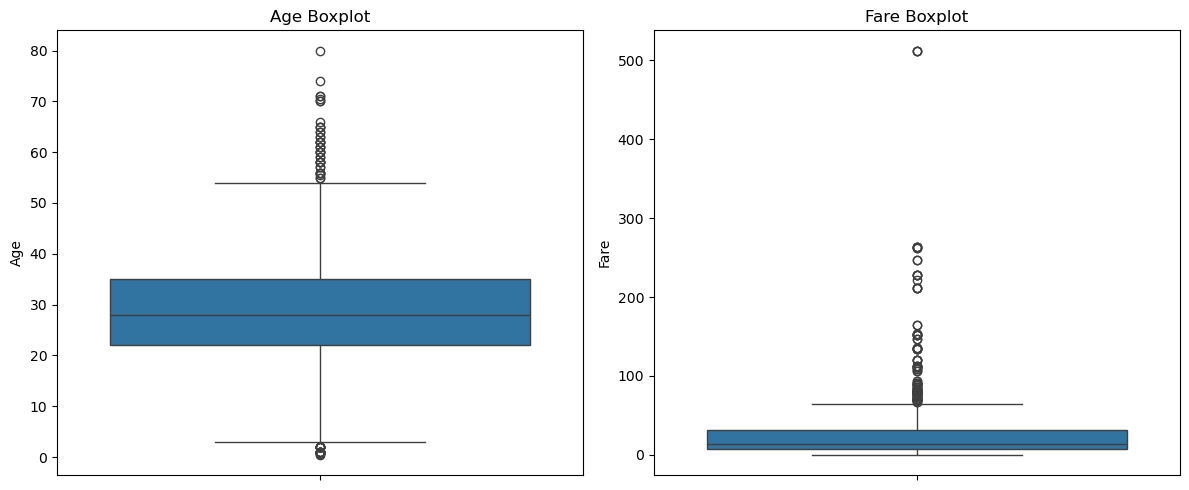


Shape After Outlier Removal:
(577, 8)

Data After Scaling:
   Survived  Pclass  Sex       Age     SibSp  Parch      Fare  Embarked
0         0       3    1 -0.854761  1.800735    0.0 -0.609448         2
2         1       3    0 -0.386610 -0.448235    0.0 -0.555858         2
3         1       1    0  0.666730  1.800735    0.0  3.030715         2
4         0       3    1  0.666730 -0.448235    0.0 -0.545934         2
5         0       3    1 -0.152535 -0.448235    0.0 -0.513517         1

Final Dataset Info:
<class 'pandas.core.frame.DataFrame'>
Index: 577 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  577 non-null    int64  
 1   Pclass    577 non-null    int64  
 2   Sex       577 non-null    int64  
 3   Age       577 non-null    float64
 4   SibSp     577 non-null    float64
 5   Parch     577 non-null    float64
 6   Fare      577 non-null    float64
 7   Embarked  577 non-null    int64 

In [1]:
# ==========================================
# TASK 1: DATA CLEANING & PREPROCESSING
# ==========================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# ==========================================
# 1. LOAD DATASET
# ==========================================

df = pd.read_csv(r"C:\Users\Bhargavi sai\Downloads\Titanic-Dataset.csv")

print("First 5 Rows:")
print(df.head())

# ==========================================
# 2. EXPLORE DATASET
# ==========================================

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
print(df.describe())

# ==========================================
# 3. HANDLE MISSING VALUES
# ==========================================

# Fill Age with median
df['Age'] = df['Age'].fillna(df['Age'].median())

# Fill Embarked with mode
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Drop Cabin column
df.drop('Cabin', axis=1, inplace=True)

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

# ==========================================
# 4. ENCODE CATEGORICAL FEATURES
# ==========================================

encoder = LabelEncoder()

df['Sex'] = encoder.fit_transform(df['Sex'])
df['Embarked'] = encoder.fit_transform(df['Embarked'])

print("\nEncoded Columns:")
print(df[['Sex', 'Embarked']].head())

# ==========================================
# 5. DROP UNNECESSARY COLUMNS
# ==========================================

df.drop(['PassengerId', 'Name', 'Ticket'], axis=1, inplace=True)

print("\nColumns Remaining:")
print(df.columns)

# ==========================================
# 6. VISUALIZE OUTLIERS
# ==========================================

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(y=df['Age'])
plt.title("Age Boxplot")

plt.subplot(1,2,2)
sns.boxplot(y=df['Fare'])
plt.title("Fare Boxplot")

plt.tight_layout()
plt.show()

# ==========================================
# 7. REMOVE OUTLIERS USING IQR
# ==========================================

numerical_cols = ['Age', 'Fare', 'SibSp', 'Parch']

for col in numerical_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    df = df[
        (df[col] >= lower_limit) &
        (df[col] <= upper_limit)
    ]

print("\nShape After Outlier Removal:")
print(df.shape)

# ==========================================
# 8. STANDARDIZE NUMERICAL FEATURES
# ==========================================

scaler = StandardScaler()

df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

print("\nData After Scaling:")
print(df.head())

# ==========================================
# 9. FINAL DATASET
# ==========================================

print("\nFinal Dataset Info:")
print(df.info())

print("\nFinal Shape:")
print(df.shape)

# ==========================================
# 10. SAVE CLEANED DATASET
# ==========================================

df.to_csv("Titanic_Cleaned.csv", index=False)

print("\nTitanic_Cleaned.csv saved successfully!")



